# EDA STROKE

Notebook: análise descritiva e exploratória do dataset STROKE. Execute todas as células para gerar os artefatos em `../eda_reports/` (subpastas: `csv`, `images`, `pdf`).

In [15]:
# Configura caminhos e imports
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.backends.backend_pdf import PdfPages
from fpdf import FPDF

# Global output settings
OUTPUT_DPI = 800  # change this value to control DPI for all saved images
PDF_FILENAME = 'EDA_STROKE_report.v1.pdf'
DUPLICATE_ROWS = None
LINHAS_INICIAIS = None
COLUNAS_INICIAIS = None
BASE = os.path.join('..','')
RAW = os.path.join('..','data','raw')
IMAGES = os.path.join('..','eda_reports','images')
CSV_DIR = os.path.join('..','eda_reports','csv')
PDF_DIR = os.path.join('..','eda_reports','pdf')
os.makedirs(IMAGES, exist_ok=True)
os.makedirs(CSV_DIR, exist_ok=True)
os.makedirs(PDF_DIR, exist_ok=True)
EXCLUDE_COLUMNS = ['__cls_tmp__', 'id','stroke', 'y', 'orig_index', 'stroke','id', 'ID', 'patient_id', 'pid', 'fold', 'y_train', 'prob_0', 'prob_1', 'y_proba', 'y_pred']
COLS_TO_REMOVE_LITERATURE = [] 
COLS_TO_REMOVE_MISSING = []
COLS_TO_INPUTATION = ['bmi']


# Ajustes visuais
sns.set(style='whitegrid')

In [16]:
# Carrega dataset - ajusta automaticamente se houver um CSV em data/raw ou em eda_reports/csv
fn_raw = [f for f in os.listdir(RAW) if f.lower().endswith('.csv')]
if len(fn_raw) == 0:
    raise FileNotFoundError(f'Nenhum CSV encontrado em {RAW}. Coloque o healthcare_stroke_data.csv em data/raw e reexecute.')
csv_path = os.path.join(RAW, fn_raw[0])  # corrigido: usar fn_raw em vez de fn
print('Carregando:', csv_path)
# Leitura defensiva: tenta inferir separador e encoding simples
try:
    df = pd.read_csv(csv_path, sep=';')
except Exception:
    # tenta com sep=';' como fallback
    df = pd.read_csv(csv_path, sep=',')

# Remover colunas identificadoras (ID) desde o início para que não apareçam em nenhuma análise
id_candidates = [c for c in df.columns if c.lower() in ('id','patient_id','patientid','record_id','serial_number')]

df['hypertension'] = df['hypertension'].map({0:'No', 1:'Yes'})
df['heart_disease'] = df['heart_disease'].map({0:'No', 1:'Yes'})
df.head()

Carregando: ../data/raw/healthcare_stroke_data.csv


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,No,Yes,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,No,No,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,No,Yes,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,No,No,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,Yes,No,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [17]:

df.dropna(inplace=True)    
df.describe(include='all')
df.isna().sum() 
df['gender'].unique()

array(['Male', 'Female', 'Other'], dtype=object)

In [18]:
# Identifica colunas numéricas e categóricas (detecção robusta)
# Primeiro tenta detectar tipos numéricos pelo dtype
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Se nenhum numeric por dtype, tenta heurística: coluna é numérica se ao menos 1 valor for convertível para número
if len(num_cols) == 0:
    coerced_counts = {}
    for c in df.columns:
        try:
            coerced_counts[c] = pd.to_numeric(df[c], errors='coerce').notnull().sum()
        except Exception:
            coerced_counts[c] = 0
    # considerar coluna numérica se houver ao menos 1 valor numérico detectado
    num_cols = [c for c, n in coerced_counts.items() if n > 0]
cat_cols = [c for c in df.columns if c not in num_cols]

#identifica duplicidades , grava arquivo de duplicadaos e remove duplicados do dataset 
LINHAS_INICIAIS = df.shape[0]
COLUNAS_INICIAIS = df.shape[1]
#identifica duplicidades , grava arquivo de duplicadaos e remove duplicados do dataset 
# Colunas consideradas para a checagem de duplicidade
cols_consider = [c for c in df.columns if c not in set(EXCLUDE_COLUMNS)]

if len(cols_consider) == 0:
    DUPLICATE_ROWS = df.duplicated(keep='first')
else:
    DUPLICATE_ROWS = df.duplicated(subset=cols_consider, keep='first')

if DUPLICATE_ROWS.sum() > 0:
    print(f'Encontradas {DUPLICATE_ROWS.sum()} linhas DUPLICATE_ROWS. Gravando arquivo de DUPLICATE_ROWS e removendo do dataset.')
    df[DUPLICATE_ROWS].to_csv(os.path.join(CSV_DIR, 'DUPLICATE_ROWS.csv'), index=False)
    df = df[~DUPLICATE_ROWS]
    print('Novas dimensões após remoção de duplicados:', df.shape)

# Remover possíveis identificadores (ID) das análises
id_candidates = [c for c in df.columns if c.lower() in ('id','stroke','patient_id','patientid','record_id','serial_number')]
if id_candidates:
    print('Removing identifier columns from analysis:', id_candidates)
    num_cols = [c for c in num_cols if c not in id_candidates]
    cat_cols = [c for c in cat_cols if c not in id_candidates]
print('Numéricas:', len(num_cols), 'Categóricas:', len(cat_cols))

# Estatísticas descritivas - numéricas (se existirem)
from scipy.stats import skew, kurtosis
if len(num_cols) > 0:
    # coerce safe numeric subset
    desc = df[num_cols].apply(lambda x: pd.to_numeric(x, errors='coerce')).describe().T
    try:
        desc['skewness'] = df[num_cols].apply(lambda x: skew(pd.to_numeric(x, errors='coerce').dropna()))
        desc['kurtosis'] = df[num_cols].apply(lambda x: kurtosis(pd.to_numeric(x, errors='coerce').dropna()))
    except Exception:
        # se cálculo falhar para alguma coluna, continue sem interromper
        pass
    display(desc)
else:
    print('Nenhuma coluna numérica detectada - pulando estatísticas descritivas numéricas')

# Frequências - categóricas (se houver)
for c in cat_cols[:10]:
    try:
        print('---', c, '---')
        display(df[c].value_counts(dropna=False).head(20))
    except Exception as e:
        print('Falha ao mostrar frequências para', c, e)

Removing identifier columns from analysis: ['id', 'stroke']
Numéricas: 3 Categóricas: 7


,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
age,4909.0,42.865374,22.555115,0.08,25.00,44.00,60.00,82.00,-0.119033,-0.988307
avg_glucose_level,4909.0,105.305150,44.424341,55.12,77.07,91.68,113.57,271.74,1.613533,1.902438
bmi,4909.0,28.893237,7.854067,10.30,23.50,28.10,33.10,97.60,1.055018,3.358013


--- gender ---


gender
Female    2897
Male      2011
Other        1
Name: count, dtype: int64

--- hypertension ---


...

work_type
Private          2811
Self-employed     775
children          671
Govt_job          630
Never_worked       22
Name: count, dtype: int64

--- Residence_type ---


Residence_type
Urban    2490
Rural    2419
Name: count, dtype: int64

--- smoking_status ---


smoking_status
never smoked       1852
Unknown            1483
formerly smoked     837
smokes              737
Name: count, dtype: int64

/tmp/ipykernel_13081/2597532220.py:133: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=s, order=order, ax=ax, palette=palette)
/tmp/ipykernel_13081/2597532220.py:133: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=s, order=order, ax=ax, palette=palette)
/tmp/ipykernel_13081/2597532220.py:133: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=s, order=order, ax=ax, palette=palette)
/tmp/ipykernel_13081/2597532220.py:133: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `

Figura salva em: ../eda_reports/images/balance_categorical_selected.png


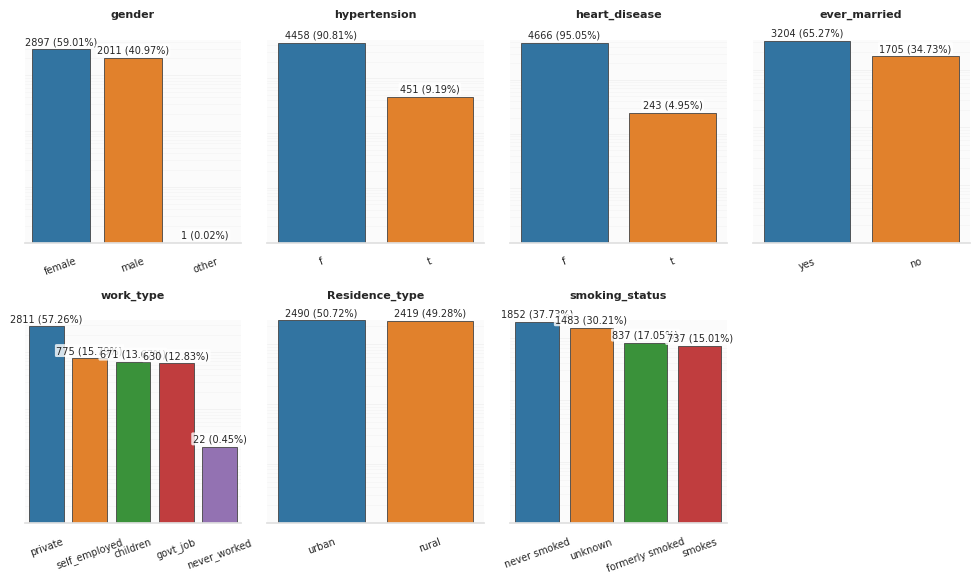

In [19]:
# Balanceamento das variáveis categóricas selecionadas
# - Detecta 2 categorias (binária) x 3+ (multiclasse)
# - Binárias: paleta azul/laranja (mantida)
# - Multiclasse: paleta com 1 cor por categoria
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import textwrap
import pandas as pd

sns.set_theme(style='whitegrid', rc={
    'axes.edgecolor': '#E0E0E0',
    'grid.color': '#DADADA',
    'grid.linewidth': 0.6,
    'axes.labelsize': 8,
    'font.size': 8
})

# ---- Variáveis a plotar (somente as que existirem no df) ----
VARS = [
    'gender', 'hypertension', 'heart_disease', 'ever_married',
    'work_type', 'Residence_type', 'smoking_status'
]
VARS = [c for c in VARS if c in df.columns]
if not VARS:
    print("Nenhuma das variáveis solicitadas está no DataFrame.")
else:
    # Paletas
    PALETTE_BINARY = ['#1f77b4', '#ff7f0e']  # azul/laranja
    DEFAULT_MULTI = 'tab10'                  # paleta base p/ multiclasse

    # ---- Normalizadores específicos por coluna ----
    def norm_generic(s: pd.Series):
        """Normalização genérica (trim, lower, NaNs reais)"""
        s = s.astype(str).str.strip()
        s = s.replace({'': np.nan, 'nan': np.nan, 'None': np.nan, 'NONE': np.nan, '-': np.nan})
        return s

    def norm_binary_tf(s: pd.Series):
        """Normaliza para 't'/'f' a partir de 0/1/true/false/yes/no/y/n"""
        s = s.astype(str).str.strip().str.lower()
        s = s.replace({'': np.nan, 'nan': np.nan, 'none': np.nan, '-': np.nan})
        s = s.replace({
            'true': 't', 't': 't', '1': 't', 'yes': 't', 'y': 't',
            'false': 'f', 'f': 'f', '0': 'f', 'no': 'f', 'n': 'f'
        })
        return s

    def norm_ever_married(s: pd.Series):
        s = s.astype(str).str.strip().str.lower()
        s = s.replace({'': np.nan, 'nan': np.nan, 'none': np.nan, '-': np.nan})
        s = s.replace({'yes':'yes', 'y':'yes', 'true':'yes', '1':'yes',
                       'no':'no', 'n':'no', 'false':'no', '0':'no'})
        return s

    def norm_gender(s: pd.Series):
        s = s.astype(str).str.strip().str.lower()
        s = s.replace({'': np.nan, 'nan': np.nan, 'none': np.nan, '-': np.nan})
        # mapeia variações comuns
        s = s.replace({'male':'male', 'm':'male', 'masculino':'male',
                       'female':'female', 'f':'female', 'feminino':'female'})
        # outros valores permanecem (ex.: 'other')
        return s

    def norm_residence(s: pd.Series):
        s = s.astype(str).str.strip().str.lower()
        s = s.replace({'': np.nan, 'nan': np.nan, 'none': np.nan, '-': np.nan})
        s = s.replace({'urban':'urban', 'u':'urban', 'rural':'rural', 'r':'rural'})
        return s

    def norm_work_type(s: pd.Series):
        s = norm_generic(s).str.lower()
        # padroniza rótulos conhecidos
        s = s.replace({
            'govt_job': 'govt_job', 'govt job': 'govt_job',
            'self-employed':'self_employed', 'self employed':'self_employed',
            'never_worked':'never_worked', 'never worked':'never_worked'
        })
        return s

    def norm_smoking(s: pd.Series):
        s = norm_generic(s).str.lower()
        s = s.replace({
            'never smoked':'never smoked',
            'formerly smoked':'formerly smoked',
            'smokes':'smokes',
            'unknown':'unknown'
        })
        return s

    NORMALIZERS = {
        'hypertension': norm_binary_tf,
        'heart_disease': norm_binary_tf,
        'ever_married': norm_ever_married,
        'Residence_type': norm_residence,
        'gender': norm_gender,
        'work_type': norm_work_type,
        'smoking_status': norm_smoking
    }

    # ---- Preparar subplots ----
    cols = 4
    rows = (len(VARS) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(10, 6), constrained_layout=False)
    fig.patch.set_facecolor('white')
    axes = np.atleast_1d(axes).flatten()

    for i, c in enumerate(VARS):
        ax = axes[i]
        ax.set_facecolor('#fbfbfb')

        s = df[c].copy()
        s = NORMALIZERS.get(c, norm_generic)(s)

        # categorias sem NaN, em ordem decrescente de frequência
        counts = s.value_counts(dropna=True)
        order = counts.index.tolist()
        n_cat = len(order)

        # Define paleta
        if n_cat <= 1:
            # nada para plotar (ou só uma categoria)
            ax.set_title(textwrap.fill(c, width=30), fontsize=8, fontweight='bold', pad=16)
            ax.text(0.5, 0.5, 'Categoria única ou vazia', ha='center', va='center', fontsize=7)
            ax.axis('off')
            continue
        elif n_cat == 2:
            palette = PALETTE_BINARY
        else:
            palette = sns.color_palette(DEFAULT_MULTI, n_cat)

        sns.countplot(x=s, order=order, ax=ax, palette=palette)

        # Título
        ax.set_title(textwrap.fill(str(c), width=30), fontsize=8, fontweight='bold', pad=16)
        ax.set_xlabel('')
        ax.set_ylabel('')
        ax.tick_params(axis='y', which='both', labelleft=False)
        ax.tick_params(axis='x', labelsize=7, rotation=20)

        # Escala log10 no Y
        ax.set_yscale('log')
        denom = s.notna().sum()

        # Borda nas barras + anotações
        for p in ax.patches:
            try:
                p.set_linewidth(0.6)
                p.set_edgecolor('#444444')
            except Exception:
                pass
            height = p.get_height()
            if height and height > 0 and denom > 0:
                pct = height / denom * 100.0
                ax.annotate(f'{int(height)} ({pct:.2f}%)',
                            (p.get_x() + p.get_width() / 2., height),
                            ha='center', va='bottom', fontsize=7,
                            xytext=(0, 2), textcoords='offset points',
                            bbox=dict(boxstyle='round,pad=0.15', fc='white', ec='none', alpha=0.8))

        ax.grid(axis='y', which='major', linestyle='-', alpha=0.3)
        ax.grid(axis='y', which='minor', linestyle='-', alpha=0.15)
        ax.set_ylim(bottom=1)
        sns.despine(ax=ax, left=True, right=True, top=True, bottom=False)

    # Remove eixos extras
    last_i = len(VARS) - 1
    for j in range(last_i + 1, len(axes)):
        fig.delaxes(axes[j])

    # Salvar
    try:
        try:
            IMAGES
        except NameError:
            IMAGES = os.path.join(BASE, 'eda_reports', 'images') if 'BASE' in globals() else os.path.join('eda_reports','images')
        os.makedirs(IMAGES, exist_ok=True)
        dpi = OUTPUT_DPI if 'OUTPUT_DPI' in globals() else 300
        out_path = os.path.join(IMAGES, 'balance_categorical_selected.png')
        plt.tight_layout(pad=1.6, w_pad=0.8, h_pad=1.2)
        plt.savefig(out_path, dpi=dpi, bbox_inches='tight')
        print(f'Figura salva em: {out_path}')
    except Exception as e:
        print('Falha ao salvar figura:', e)

    plt.show()


In [20]:
# Helper cell: compute VIF values from numeric features (including binary 't'/'f') and save to CSV_DIR/vif_values.csv
# This allows the metrics cell to pick up VIFs without relying on external files.
import os
import numpy as np
import pandas as pd

try:
    # Make a working copy and encode binary 't'/'f' style features
    df_enc = df.copy()

    def maybe_encode_binary_tf(series: pd.Series) -> pd.Series:
        if series.dtype == object:
            s = series.astype(str).str.strip().str.lower()
            uniq = set(s.dropna().unique())
            allowed = {'t','f','true','false','0','1'}
            if len(uniq) > 0 and uniq.issubset(allowed):
                mapped = s.map({'t':1, 'true':1, '1':1, 'f':0, 'false':0, '0':0})
                return pd.to_numeric(mapped, errors='coerce')
            # Try numeric coercion for numeric-like strings
            coerced = pd.to_numeric(series, errors='coerce')
            # If at least half are numeric after coercion, keep it
            if coerced.notna().sum() >= 0.5 * len(series):
                return coerced
        return series

    for c in df_enc.columns:
        try:
            df_enc[c] = maybe_encode_binary_tf(df_enc[c])
        except Exception:
            pass

    # Prepare numeric dataframe after encoding
    num_df = df_enc.select_dtypes(include=[np.number]).copy()

    # Drop probable target/ID columns if they exist
    for tgt in ['diagnosis', 'target', 'class']:
        if tgt in num_df.columns:
            num_df = num_df.drop(columns=[tgt])
    # Drop id-like columns (to avoid inflating VIF with identifiers)
    id_like = [c for c in num_df.columns if 'id' in c.lower()]
    if id_like:
        num_df = num_df.drop(columns=id_like)

    # Drop constant columns (zero variance)
    const_cols = [c for c in num_df.columns if num_df[c].nunique(dropna=True) <= 1]
    if const_cols:
        num_df = num_df.drop(columns=const_cols)

    # Only compute if we have at least 2 features
    if num_df.shape[1] >= 2:
        # Fill missing with median to enable VIF computation
        num_df = num_df.apply(lambda s: s.fillna(s.median()))
        try:
            from statsmodels.stats.outliers_influence import variance_inflation_factor
            X = num_df.values.astype(float)
            vif_vals = []
            for i in range(X.shape[1]):
                try:
                    val = float(variance_inflation_factor(X, i))
                except Exception:
                    val = float('inf')
                vif_vals.append(val)
            vif_s = pd.Series(vif_vals, index=num_df.columns, name='vif')
            # Save to CSV in the format the metrics cell expects (index + single column)
            vif_path = os.path.join(CSV_DIR, 'vif_values.csv')
            vif_s.to_frame().to_csv(vif_path)
            print(f'VIF salvo em: {vif_path} (features: {len(vif_s)})')
        except Exception as e:
            print('Não foi possível calcular VIF automaticamente (statsmodels ausente ou outro erro):', e)
    else:
        print('VIF não calculado: menos de 2 variáveis numéricas válidas após limpeza.')
except Exception as e:
    print('Erro inesperado ao calcular/salvar VIF:', e)

VIF salvo em: ../eda_reports/csv/vif_values.csv (features: 4)


In [21]:
# Ensure CSV_DIR is defined and directory exists (fallback)
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from math import log2
from IPython.display import display

# Fallbacks from earlier cells if not defined
try:
    CSV_DIR  # type: ignore
except NameError:
    CSV_DIR = os.path.abspath(os.path.join('..', 'eda_reports', 'csv'))
os.makedirs(CSV_DIR, exist_ok=True)

try:
    OUTPUT_DPI  # type: ignore
except NameError:
    OUTPUT_DPI = 150

try:
    save_fig  # type: ignore
except NameError:
    def save_fig(fig, filename, dpi=150):
        outdir = os.path.abspath(os.path.join('..', 'eda_reports', 'images'))
        os.makedirs(outdir, exist_ok=True)
        fig.savefig(os.path.join(outdir, filename), dpi=dpi, bbox_inches='tight')

# Consider only numeric variables: age, avg_glucose_level, bmi
num_cols_req = ['age', 'avg_glucose_level', 'bmi']
avail_cols = [c for c in num_cols_req if c in df.columns]
if not avail_cols:
    print('Nenhuma das colunas numéricas requisitadas foi encontrada:', num_cols_req)
else:
    # Missingness summary: counts and percent - salva tabela e figura
    missing_counts = df[avail_cols].isnull().sum()
    missing_pct = df[avail_cols].isnull().mean() * 100
    missing_df = pd.DataFrame({
        'nulos': [f"{int(v)} - {round((v/df.shape[0]*100) if df.shape[0]>0 else 0,1)}%" for v in missing_counts]
    }, index=missing_counts.index)
    missing_df = missing_df.sort_values(by='nulos', key=lambda s: s.apply(lambda x: int(str(x).split(' - ')[0])), ascending=False)
    display(missing_df.head(50))
    missing_df.to_csv(os.path.join(CSV_DIR, 'missing_summary.csv'))

    # Heatmap of missing values (if not too large)
    try:
        fig, ax = plt.subplots(figsize=(12, 6))
        sns.heatmap(df[avail_cols].isnull(), cbar=False, yticklabels=False, cmap='viridis', ax=ax)
        ax.set_title('Missingness map (rows x cols)')
        save_fig(fig, 'missingness_matrix.png', dpi=OUTPUT_DPI)
        plt.close(fig)
    except Exception as e:
        print('Não foi possível gerar missingness heatmap:', e)

    # Utilitários: outliers (IQR), entropia para numérico/categórico
    def iqr_outliers(series_num: pd.Series):
        s = series_num.dropna().astype(float)
        if s.empty:
            return 0, 0.0
        q1 = s.quantile(0.25)
        q3 = s.quantile(0.75)
        iqr = q3 - q1
        if iqr == 0:
            return 0, 0.0
        low = q1 - 1.5*iqr
        high = q3 + 1.5*iqr
        mask = (s < low) | (s > high)
        count = int(mask.sum())
        pct = (count / len(series_num) * 100.0) if len(series_num) else 0.0
        return count, pct

    def entropy_feature(ser: pd.Series, max_bins: int = 20):
        """
        Calcula a entropia de Shannon (raw) e a entropia normalizada (0..1).
        - Numéricas: discretização em até `max_bins` bins.
        - Categóricas: frequências por categoria.
        Retorna: (entropia_raw, entropia_normalizada)
        """
        s = ser.dropna()
        if s.empty:
            return float('nan'), float('nan')
        # Numérica: discretiza por bins
        if pd.api.types.is_numeric_dtype(s):
            unique_vals = s.nunique(dropna=True)
            bins = min(max_bins, max(2, unique_vals))
            try:
                binned, _ = pd.cut(s, bins=bins, include_lowest=True, retbins=True, duplicates='drop')
                counts = binned.value_counts(dropna=False).values.astype(float)
            except Exception:
                counts = s.value_counts(dropna=False).values.astype(float)
        else:
            counts = s.astype(str).value_counts(dropna=False).values.astype(float)
        probs = counts / counts.sum()
        # Entropia de Shannon (raw)
        ent_raw = -np.sum([p*log2(p) for p in probs if p > 0])
        # Normalização por log2(k)
        k = len(counts)
        if k <= 1:
            return 0.0, 0.0
        ent_norm = float(ent_raw / log2(k))
        return float(ent_raw), ent_norm

    # Mapear VIF para uma escala percentual (25%, 50%, 75%, 100%)
    # 1 -> 25%, 5 -> 50%, 10 -> 75%, >10 -> 100%
    def vif_to_percent(v):
        try:
            v = float(v)
        except Exception:
            return ''
        if np.isnan(v) or not np.isfinite(v):
            return ''
        if v <= 1:
            pct = 25.0
        elif v <= 5:
            pct = 25.0 + (v - 1.0) / 4.0 * 25.0
        elif v <= 10:
            pct = 50.0 + (v - 5.0) / 5.0 * 25.0
        else:
            pct = 100.0
        return pct

    # --- Prepare metrics per feature ---
    try:
        stats = {}
        stats_list = []
        out_iqr_series = {}
        for c in avail_cols:
            ser = df[c]
            ser_num = pd.to_numeric(ser, errors='coerce')

            # Estatísticas numéricas básicas (para variáveis numéricas)
            mean = ser_num.mean()
            std = ser_num.std()
            mn = ser_num.min()
            mx = ser_num.max()
            median = ser_num.median()
            n_total = ser.shape[0]
            n_nulls = int(ser.isna().sum())
            n_non_na_num = int(ser_num.notna().sum())

            # IC 95% da média (se aplicável)
            try:
                sem = (std / np.sqrt(n_non_na_num)) if n_non_na_num > 0 else float('nan')
                ic_low  = mean - 1.96*sem if pd.notna(sem) else float('nan')
                ic_high = mean + 1.96*sem if pd.notna(sem) else float('nan')
                ic95 = f'[{ic_low:.3f}, {ic_high:.3f}]' if pd.notna(sem) else '[]'
            except Exception:
                ic95 = '[]'

            coef_var = (std/mean) if mean and mean!=0 else float('nan')
            variance = std**2 if std==std else float('nan')

            # Moda (numérica)
            try:
                m_num = ser_num.dropna().mode()
            except Exception:
                m_num = pd.Series(dtype=float)
            if len(m_num) > 0:
                mode_val = m_num.iloc[0]
            else:
                mode_val = ''
            if pd.isna(mode_val):
                mode_val = ''

            # Outliers (IQR) e percentual – apenas para numéricas
            if n_non_na_num > 0:
                out_count, out_pct = iqr_outliers(ser_num)
                outlier_str = f"{out_count} - {round(out_pct,1)}%"
            else:
                out_count, out_pct = 0, 0.0
                outlier_str = "0 - 0.0%"
            out_iqr_series[c] = out_count

            # Entropia: valor raw e normalizado => formato "raw - pct%"
            ent_raw, ent_norm = entropy_feature(ser_num)
            if pd.isna(ent_raw) or pd.isna(ent_norm):
                ent_str = ''
            else:
                ent_str = f"{ent_raw:.5f} - {ent_norm*100:.1f}%"

            stats_list.append({
                'variable': c,
                'mean': mean,
                'std': std,
                'min': mn,
                'max': mx,
                'mediana': median,
                'ic_95': ic95,
                'coef_variacao': coef_var,
                'variancia': variance,
                'nulos': n_nulls,
                'moda': mode_val,
                'outlier': outlier_str,
                'entropy': ent_str
            })
        stats_df = pd.DataFrame(stats_list).set_index('variable')

        # VIF se existir arquivo auxiliar (mantido, mas não obrigatório)
        def safe_read_series(path, squeeze_col=0):
            try:
                if os.path.exists(path):
                    ser = pd.read_csv(path, index_col=0)
                    if ser.shape[1] >= 1:
                        return ser.iloc[:, squeeze_col]
                    return ser.iloc[:,0]
            except Exception:
                pass
            return pd.Series(index=stats_df.index, data=[float('nan')]*len(stats_df))

        try:
            vif_path = os.path.join(CSV_DIR, 'vif_values.csv')
            vif_s = safe_read_series(vif_path)
        except Exception:
            vif_s = pd.Series(index=stats_df.index, data=[float('nan')]*len(stats_df))

        # Monta métricas
        metrics = stats_df.copy()
        # Aplica transformação ao VIF: "valor - pct%" (valor com 5 casas)
        vif_vals = [vif_s.get(c, float('nan')) if hasattr(vif_s, 'get') else float('nan') for c in metrics.index]
        def format_vif(v):
            try:
                vnum = float(v)
            except Exception:
                return ''
            if np.isnan(vnum) or not np.isfinite(vnum):
                return ''
            pct = vif_to_percent(vnum)
            if pct == '':
                return f"{vnum:.5f}"
            return f"{vnum:.5f} - {pct:.1f}%"
        metrics['vif'] = [format_vif(v) for v in vif_vals]

        # Formata 'nulos' como "qtd - percentual%"
        total_rows = df.shape[0]
        metrics['nulos'] = [
            f"{int(x)} - {((int(x)/total_rows*100) if total_rows else 0):.1f}%"
            for x in pd.to_numeric(metrics['nulos'], errors='coerce').fillna(0)
        ]

        # Normalidade (Shapiro e D'Agostino) – apenas para numéricas com dados
        from scipy.stats import shapiro, normaltest
        normal_shapiro_stat = {}
        normal_shapiro_p = {}
        normal_shapiro_result = {}
        normal_dagostino_stat = {}
        normal_dagostino_p = {}
        normal_dagostino_result = {}

        for c in metrics.index:
            try:
                series = pd.to_numeric(df[c], errors='coerce').dropna()
                n = len(series)
                if n == 0:
                    normal_shapiro_stat[c] = float('nan')
                    normal_shapiro_p[c] = float('nan')
                    normal_shapiro_result[c] = 'Não - p ≤ 0.05 - 0,000'
                    normal_dagostino_stat[c] = float('nan')
                    normal_dagostino_p[c] = float('nan')
                    normal_dagostino_result[c] = 'Não - p ≤ 0.05 - 0,000'
                    continue
                sample = series.sample(n=5000, random_state=0) if n > 5000 else series

                # Shapiro-Wilk
                try:
                    s_stat, s_p = shapiro(sample)
                    s_stat = float(s_stat)
                    s_p = float(s_p)
                    normal_shapiro_stat[c] = s_stat
                    normal_shapiro_p[c] = s_p
                    p_fmt = f"{s_p:.3f}" if (s_p==s_p) else "0.000"
                    p_fmt_display = p_fmt.replace('.', ',')
                    if s_p > 0.05:
                        normal_shapiro_result[c] = f"Sim - p > 0.05 - {p_fmt_display}"
                    else:
                        normal_shapiro_result[c] = f"Não - p ≤ 0.05 - {p_fmt_display}"
                except Exception:
                    normal_shapiro_stat[c] = float('nan')
                    normal_shapiro_p[c] = float('nan')
                    normal_shapiro_result[c] = 'Não - p ≤ 0.05 - 0,000'

                # D'Agostino K^2
                try:
                    if len(sample) >= 8:
                        d_stat, d_p = normaltest(sample)
                        d_stat = float(d_stat)
                        d_p = float(d_p)
                        normal_dagostino_stat[c] = d_stat
                        normal_dagostino_p[c] = d_p
                        p_fmt = f"{d_p:.3f}" if (d_p==d_p) else "0.000"
                        p_fmt_display = p_fmt.replace('.', ',')
                        if d_p > 0.05:
                            normal_dagostino_result[c] = f"Sim - p > 0.05 - {p_fmt_display}"
                        else:
                            normal_dagostino_result[c] = f"Não - p ≤ 0.05 - {p_fmt_display}"
                    else:
                        normal_dagostino_stat[c] = float('nan')
                        normal_dagostino_p[c] = float('nan')
                        normal_dagostino_result[c] = 'Não - p ≤ 0.05 - 0,000'
                except Exception:
                    normal_dagostino_stat[c] = float('nan')
                    normal_dagostino_p[c] = float('nan')
                    normal_dagostino_result[c] = 'Não - p ≤ 0.05 - 0,000'

            except Exception:
                normal_shapiro_stat[c] = float('nan')
                normal_shapiro_p[c] = float('nan')
                normal_shapiro_result[c] = 'Não - p ≤ 0.05 - 0,000'
                normal_dagostino_stat[c] = float('nan')
                normal_dagostino_p[c] = float('nan')
                normal_dagostino_result[c] = 'Não - p ≤ 0.05 - 0,000'

        # Build normality DataFrame and save
        normality_df = pd.DataFrame(index=metrics.index)
        normality_df['shapiro_stat'] = pd.Series(normal_shapiro_stat)
        normality_df['shapiro_p'] = pd.Series(normal_shapiro_p)
        normality_df['shapiro_result'] = pd.Series(normal_shapiro_result)
        normality_df['dagostino_stat'] = pd.Series(normal_dagostino_stat)
        normality_df['dagostino_p'] = pd.Series(normal_dagostino_p)
        normality_df['dagostino_result'] = pd.Series(normal_dagostino_result)

        try:
            normality_df.to_csv(os.path.join(CSV_DIR, 'normality_tests.csv'))
        except Exception as e:
            print('Falha ao salvar normality_tests.csv:', e)

        # Add normal results to metrics (detailed + aggregated)
        metrics['normal_shapiro'] = normality_df['shapiro_result']
        metrics['normal_shapiro_stat'] = normality_df['shapiro_stat']
        metrics['normal_shapiro_p'] = normality_df['shapiro_p']
        metrics['normal_dagostino'] = normality_df['dagostino_result']
        metrics['normal_dagostino_stat'] = normality_df['dagostino_stat']
        metrics['normal_dagostino_p'] = normality_df['dagostino_p']

        # Aggregated 'normal' decision
        normal_agg = []
        for c in metrics.index:
            s_res = metrics.at[c, 'normal_shapiro'] if 'normal_shapiro' in metrics.columns else 'Não - p ≤ 0.05 - 0,000'
            d_res = metrics.at[c, 'normal_dagostino'] if 'normal_dagostino' in metrics.columns else 'Não - p ≤ 0.05 - 0,000'
            try:
                s_p = metrics.at[c, 'normal_shapiro_p'] if pd.notnull(metrics.at[c, 'normal_shapiro_p']) else float('nan')
            except Exception:
                s_p = float('nan')
            try:
                d_p = metrics.at[c, 'normal_dagostino_p'] if pd.notnull(metrics.at[c, 'normal_dagostino_p']) else float('nan')
            except Exception:
                d_p = float('nan')
            s_is_sim = isinstance(s_res, str) and s_res.startswith('Sim')
            d_is_sim = isinstance(d_res, str) and d_res.startswith('Sim')
            if s_is_sim and d_is_sim:
                chosen_p = max([p for p in [s_p, d_p] if p==p], default=float('nan'))
                p_fmt = f"{chosen_p:.3f}" if (chosen_p==chosen_p) else "0.000"
                p_disp = p_fmt.replace('.', ',')
                normal_agg.append(f"Sim - p > 0.05 - {p_disp}")
            else:
                chosen_p = min([p for p in [s_p, d_p] if p==p], default=0.0)
                p_fmt = f"{chosen_p:.3f}" if (chosen_p==chosen_p) else "0.000"
                p_disp = p_fmt.replace('.', ',')
                normal_agg.append(f"Não - p ≤ 0.05 - {p_disp}")

        metrics['normal'] = normal_agg

        # drop helper column if present
        if 'percentual_nulos' in metrics.columns:
            metrics = metrics.drop(columns=['percentual_nulos'])

        # format numeric columns to 3 decimals (não incluir 'moda', 'nulos', 'entropy', 'vif' que agora são strings)
        numcols = ['mean','std','min','max','mediana','coef_variacao','variancia','normal_shapiro_stat','normal_shapiro_p','normal_dagostino_stat','normal_dagostino_p']
        for nc in numcols:
            if nc in metrics.columns:
                metrics[nc] = metrics[nc].apply(lambda x: round(x,3) if (pd.notnull(x) and isinstance(x,(int,float,np.floating))) else x)

        # save metrics CSV (NaN em branco)
        metrics.to_csv(os.path.join(CSV_DIR, 'feature_metrics_full.csv'), na_rep='')

        # render as wide table image (landscape) with smaller font; include 'entropy' and 'normal' columns
        rows_per_page = 60
        total_rows = metrics.shape[0]
        pages = (total_rows + rows_per_page - 1) // rows_per_page
        for p in range(pages or 1):
            start = p*rows_per_page
            HIDE_COLS = ['normal_shapiro_stat','normal_shapiro_p','normal_dagostino_stat','normal_dagostino_p', 'normal_shapiro', 'normal_dagostino']
            tmp = metrics.reset_index()

            # 🔹 remove linhas onde a coluna 'variable' (ou índice) seja 'diagnosis'
            if 'variable' in tmp.columns:
                tmp = tmp[tmp['variable'] != 'diagnosis']
            else:
                tmp = tmp[tmp.index != 'diagnosis']

            tbl = tmp.drop(columns=[c for c in HIDE_COLS if c in tmp.columns]) \
                    .iloc[start:start+rows_per_page]

            # Substituir NaN por string vazia para evitar 'nan' no PNG
            tbl_display = tbl.replace({np.nan: ''})

            fig, ax = plt.subplots(figsize=(13.0, 8.57))
            ax.axis('off')
            ax.set_title(f'Feature metrics (page {p+1}/{max(pages,1)})', fontsize=12)
            # compute column widths to reduce whitespace for numeric columns
            cols = tbl_display.columns.tolist()
            # default width
            default_w = 0.08
            col_widths_map = {
                'variable': 0.12,
                'mean': 0.045,
                'std': 0.045,
                'min': 0.04,
                'max': 0.04,
                'mediana': 0.045,
                'ic_95': 0.12,
                'coef_variacao': 0.06,
                'nulos': 0.07,
                'vif': 0.13,
                'outlier': 0.07,
                'entropy': 0.13,
                'moda': 0.08,
                'normal': 0.11
            }
            widths = [col_widths_map.get(c, default_w) for c in cols]
            cell_text = [cols] + tbl_display.values.tolist()
            # create table with specified column widths
            table = ax.table(cellText=cell_text, loc='center', cellLoc='left', colWidths=widths)
            table.auto_set_font_size(False)
            table.set_fontsize(7)
            # slightly reduce vertical padding
            table.scale(1.0, 0.75)
            plt.subplots_adjust(left=0.02, right=0.98, top=0.88, bottom=0.02)
            save_fig(fig, f'metrics_landscape_page_{p+1}.png', dpi=OUTPUT_DPI)
            plt.close(fig)

    except Exception as e:
        print('Failed to build metrics_landscape PNG:', e)

,nulos
age,0 - 0.0%
avg_glucose_level,0 - 0.0%
bmi,0 - 0.0%


Saved ../eda_reports/images/missingness_matrix.png (dpi=800)
Saved ../eda_reports/images/metrics_landscape_page_1.png (dpi=800)


Figura salva em: ../eda_reports/images/outliers_scatter_iqr_core.png


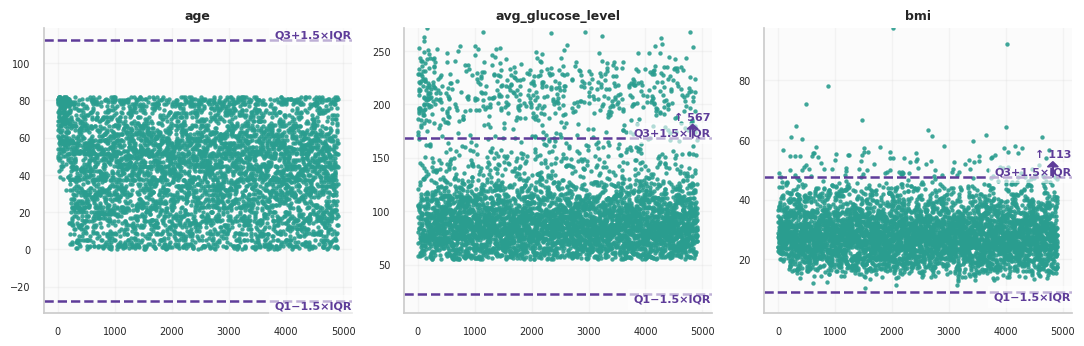

CSV de outliers (Tukey 1.5*IQR) salvo em: ../eda_reports/csv/outliers_iqr_core.csv (linhas: 650)
Linhas removidas do df por regra Tukey 1.5*IQR: 650 (antes=4909, depois=4259)


In [22]:
# [IQR - Tukey 1.5*IQR] Scatter por variável numérica (APENAS: age, avg_glucose_level/avg_glicose_level, bmi)
# - Plota e anota outliers
# - Salva CSV com outliers e flags
# - Atualiza df removendo linhas outliers
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
import unicodedata

sns.set_theme(style='whitegrid')

# ------------------ Utilidades ------------------
def _normalize_name(name: str) -> str:
    s = unicodedata.normalize('NFKD', str(name))
    s = s.encode('ascii', 'ignore').decode('ascii')
    s = s.lower()
    s = re.sub(r'\(.*?\)', '', s)
    s = re.sub(r'[^a-z0-9]+', '_', s).strip('_')
    return s

# Mapeia variações para nomes-alvo
NAME_ALIASES = {
    'age': ['age', 'idade'],
    'avg_glucose_level': ['avg_glucose_level', 'avg_glicose_level', 'avg_glucose', 'glucose_avg'],
    'bmi': ['bmi', 'imc']
}

def _resolve_columns(df):
    present = {}
    norm_cols = {_normalize_name(c): c for c in df.columns}
    for key, aliases in NAME_ALIASES.items():
        found = None
        for a in aliases:
            na = _normalize_name(a)
            if na in norm_cols:
                found = norm_cols[na]
                break
        present[key] = found
    return present

colmap = _resolve_columns(df)

# Somente colunas existentes
target_cols = {k: v for k, v in colmap.items() if v is not None}
if not target_cols:
    raise RuntimeError("Nenhuma das variáveis ['age', 'avg_glucose_level/avg_glicose_level', 'bmi'] foi encontrada no DataFrame.")

# Série numérica segura
def _to_numeric_series(s: pd.Series) -> pd.Series:
    return pd.to_numeric(s, errors='coerce')

# ------------------ PLOTS (3 colunas) ------------------
cols = 3
rows = 1
fig, axes = plt.subplots(rows, cols, figsize=(11, 3.6), constrained_layout=False)
axes = np.atleast_1d(axes).flatten()
fig.patch.set_facecolor('white')

point_color = '#2a9d8f'   # teal
tukey_color = '#5e3c99'   # roxo escuro

ordered_keys = ['age', 'avg_glucose_level', 'bmi']
ordered_keys = [k for k in ordered_keys if k in target_cols]

for i in range(cols):
    if i >= len(ordered_keys):
        fig.delaxes(axes[i])
        continue
    key = ordered_keys[i]
    c = target_cols[key]
    ax = axes[i]
    ax.set_facecolor('#fbfbfb')

    s = _to_numeric_series(df[c])
    idx = np.arange(len(s))
    ax.scatter(idx, s, s=10, c=point_color, alpha=0.9, linewidths=0)

    s_non = s.dropna()
    if len(s_non) >= 2:
        q1 = float(np.nanpercentile(s_non, 25))
        q3 = float(np.nanpercentile(s_non, 75))
        iqr = q3 - q1
        low_t = q1 - 1.5 * iqr
        high_t = q3 + 1.5 * iqr

        ax.axhline(low_t, color=tukey_color, linestyle='--', linewidth=1.8, alpha=1.0, zorder=2)
        ax.axhline(high_t, color=tukey_color, linestyle='--', linewidth=1.8, alpha=1.0, zorder=2)

        n_below = int((s <= low_t).sum())
        n_above = int((s >= high_t).sum())

        y_min_data = float(np.nanmin(s_non))
        y_max_data = float(np.nanmax(s_non))
        y_rng = max(1e-9, y_max_data - y_min_data)
        y_low_plot = min(y_min_data, low_t - 0.08 * y_rng)
        y_high_plot = max(y_max_data, high_t + 0.08 * y_rng)
        ax.set_ylim(y_low_plot, y_high_plot)

        x0, x1 = ax.get_xlim()
        ax.text(x1, high_t, 'Q3+1.5×IQR', fontsize=8, color=tukey_color, weight='bold',
                va='bottom', ha='right', bbox=dict(facecolor='white', edgecolor='none', alpha=0.6))
        ax.text(x1, low_t, 'Q1−1.5×IQR', fontsize=8, color=tukey_color, weight='bold',
                va='top', ha='right', bbox=dict(facecolor='white', edgecolor='none', alpha=0.6))

        x_arrow = x1 - 0.06 * (x1 - x0)
        if n_above > 0:
            dy = 0.06 * y_rng
            ax.arrow(x_arrow, high_t, 0, dy, length_includes_head=True,
                     head_width=0.035 * (x1 - x0), head_length=0.02 * y_rng,
                     fc=tukey_color, ec=tukey_color, linewidth=1.0, zorder=3)
            ax.text(x_arrow, high_t + dy + 0.01 * y_rng, f"↑ {n_above}",
                    fontsize=8, color=tukey_color, weight='bold', va='bottom', ha='center')
        if n_below > 0:
            dy = -0.06 * y_rng
            ax.arrow(x_arrow, low_t, 0, dy, length_includes_head=True,
                     head_width=0.035 * (x1 - x0), head_length=0.02 * y_rng,
                     fc=tukey_color, ec=tukey_color, linewidth=1.0, zorder=3)
            ax.text(x_arrow, low_t + dy - 0.01 * y_rng, f"↓ {n_below}",
                    fontsize=8, color=tukey_color, weight='bold', va='top', ha='center')

    ax.set_title(str(c), fontsize=9, fontweight='bold', pad=6)
    ax.set_xlabel(''); ax.set_ylabel('')
    ax.tick_params(axis='x', labelsize=7)
    ax.tick_params(axis='y', labelsize=7)
    ax.grid(axis='both', which='major', linestyle='-', alpha=0.18)
    ax.grid(axis='both', which='minor', linestyle='-', alpha=0.08)
    sns.despine(ax=ax, left=False, right=True, top=True, bottom=False)

plt.tight_layout(pad=1.0, w_pad=0.9, h_pad=0.9)

# Salvar figura
try:
    IMAGES
except NameError:
    IMAGES = os.path.join('eda_reports','images')
os.makedirs(IMAGES, exist_ok=True)
dpi = 300
out_img = os.path.join(IMAGES, 'outliers_scatter_iqr_core.png')
plt.savefig(out_img, dpi=dpi, bbox_inches='tight')
print(f'Figura salva em: {out_img}')
plt.show()

# ------------------ CSV de outliers + atualização do df ------------------
# Calcular máscaras para as colunas alvo presentes
outlier_flags = {}
combined_mask = pd.Series(False, index=df.index)

for key in ordered_keys:
    col = target_cols[key]
    s = pd.to_numeric(df[col], errors='coerce')
    s_non = s.dropna()
    if len(s_non) < 2:
        outlier_flags[key] = pd.Series(False, index=df.index)
        continue
    q1 = float(np.nanpercentile(s_non, 25))
    q3 = float(np.nanpercentile(s_non, 75))
    iqr = q3 - q1
    thr_low = q1 - 1.5 * iqr
    thr_high = q3 + 1.5 * iqr
    mask = (s <= thr_low) | (s >= thr_high)
    outlier_flags[key] = mask.fillna(False)
    combined_mask = combined_mask | outlier_flags[key]

# DataFrame de flags
flags_df = pd.DataFrame({f'out_{k}': v.astype(int) for k, v in outlier_flags.items()}, index=df.index)
flags_df['out_any'] = (flags_df.filter(like='out_').sum(axis=1) > 0).astype(int)
def _join_triggers(row):
    cols = [k.replace('out_', '') for k, v in row.items() if k.startswith('out_') and v == 1]
    return ','.join(cols)
flags_df['trigger_cols'] = flags_df.apply(_join_triggers, axis=1)

# Salvar CSV com outliers
if combined_mask.any():
    out_df = df.loc[combined_mask].copy().join(flags_df.loc[combined_mask])
    try:
        CSV_DIR
    except NameError:
        CSV_DIR = os.path.join('eda_reports','csv')
    os.makedirs(CSV_DIR, exist_ok=True)
    csv_path = os.path.join(CSV_DIR, 'outliers_iqr_core.csv')
    out_df.to_csv(csv_path, index=True)
    print(f'CSV de outliers (Tukey 1.5*IQR) salvo em: {csv_path} (linhas: {len(out_df)})')
else:
    print('Nenhum outlier (Tukey 1.5*IQR) encontrado em age/avg_glucose_level/bmi.')

# Remover do df
if combined_mask.any():
    before = len(df)
    df = df.loc[~combined_mask].copy()
    after = len(df)
    print(f'Linhas removidas do df por regra Tukey 1.5*IQR: {before - after} (antes={before}, depois={after})')
else:
    print('df não alterado: nenhuma linha removida pela regra Tukey 1.5*IQR.')


In [23]:
# Salva versão 'processed' simples para consumo posterior (parquet se possível)
processed_dir = os.path.join('..','data','processed')
os.makedirs(processed_dir, exist_ok=True)
proc_csv = os.path.join(processed_dir, os.path.basename(csv_path))
df.to_csv(os.path.join(processed_dir, 'healthcare_stroke_data_processed_cru_final.csv'), index=False)
print('Saved processed CSV:', os.path.join(processed_dir, 'healthcare_stroke_data_processed_cru_final.csv'))


Saved processed CSV: ../data/processed/healthcare_stroke_data_processed_cru_final.csv


In [24]:
def save_fig(fig, name, dpi=None):
    if dpi is None:
        dpi = OUTPUT_DPI
    path = os.path.join(IMAGES, name)
    fig.savefig(path, bbox_inches='tight', dpi=dpi)
    print(f'Saved {path} (dpi={dpi})')
    return path

# Histogramas em grid - somente colunas numéricas (robusto)
n = len(num_cols)
if n == 0:
    print('Nenhuma coluna numérica detectada - pulando histogramas e boxplots')
else:
    cols = 3
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols*4.5, rows*3.5), constrained_layout=False)
    axes = np.array(axes).flatten()
    last_i = -1
    for i, c in enumerate(num_cols):
        ax = axes[i]
        ser = pd.to_numeric(df[c], errors='coerce').dropna()
        if ser.empty:
            ax.axis('off')
            ax.text(0.5, 0.5, 'no non-NA numeric values', ha='center', va='center')
            ax.set_title(c, fontsize=10)
            last_i = i
            continue
        sns.histplot(ser, ax=ax, kde=True, color='C0')
        ax.set_title(c, fontsize=10)
        last_i = i
    # limpa e esconde eixos extras
    for j in range(last_i+1, len(axes)):
        try:
            axes[j].axis('off')
        except Exception:
            pass
    fig.subplots_adjust(hspace=0.5, wspace=0.4)
    save_fig(fig, 'histograms_grid.png')
    plt.close(fig)

    # Boxplots em grid (robusto) - evita chamar seaborn com dados inválidos
    fig, axes = plt.subplots(rows, cols, figsize=(cols*4.5, rows*3.5), constrained_layout=False)
    axes = np.array(axes).flatten()
    last_i = -1
    for i, c in enumerate(num_cols):
        ax = axes[i]
        ser = pd.to_numeric(df[c], errors='coerce').dropna()
        if ser.empty or ser.nunique() <= 1:
            ax.axis('off')
            ax.text(0.5, 0.5, 'no data or constant', ha='center', va='center')
            ax.set_title(c, fontsize=10)
            last_i = i
            continue
        try:
            sns.boxplot(x=ser, ax=ax, color='C1')
        except Exception:
            ax.axis('off')
            ax.text(0.5, 0.5, 'plot error', ha='center', va='center')
        ax.set_title(c, fontsize=10)
        last_i = i
    for j in range(last_i+1, len(axes)):
        try:
            axes[j].axis('off')
        except Exception:
            pass
    fig.subplots_adjust(hspace=0.6, wspace=0.4)
    save_fig(fig, 'boxplots_grid.png')
    plt.close(fig)

Saved ../eda_reports/images/histograms_grid.png (dpi=800)
Saved ../eda_reports/images/boxplots_grid.png (dpi=800)


In [25]:
# Correlação de Pearson e heatmap anotado apenas para |r| > 0.3 (landscape / horizontal page)
corr = df[num_cols].corr(method='pearson')
mask = corr.abs() < 0.3
# Preparar anotações: somente onde |r| >= 0.3
annot = corr.round(2).astype(str)
annot = annot.where(~mask, '')
# Use a wider figure for horizontal/landscape layout
fig_w = max(11, len(num_cols) * 0.35)
fig_h = max(6, len(num_cols) * 0.2)
fig, ax = plt.subplots(figsize=(fig_w, fig_h))
sns.heatmap(
    corr,
    mask=None,
    cmap='coolwarm',
    center=0,
    ax=ax,
    annot=annot,
    fmt='',
    annot_kws={'size':5, 'weight':'bold'},
    linewidths=0.2,
    square=False,
    cbar_kws={'shrink':1.0}
)
# reduce tick label sizes
ax.tick_params(axis='both', which='major', labelsize=7)
ax.set_title('Pearson Correlation (only |r| >= 0.3 annotated)', fontsize=12)
plt.tight_layout()
# save as a landscape PNG using OUTPUT_DPI
save_fig(fig, 'correlation_heatmap.png', dpi=OUTPUT_DPI)
plt.close(fig)


Saved ../eda_reports/images/correlation_heatmap.png (dpi=800)


In [26]:
# Normality tests (Shapiro / D'Agostino) for top skewed numeric variables - Q-Q plots removed as requested
from scipy.stats import shapiro, normaltest
# Compute skewness and pick top skewed numeric columns (stable against non-numeric)
skew_vals = df[num_cols].apply(lambda x: pd.to_numeric(x, errors='coerce').dropna().skew())
skewed = skew_vals.abs().sort_values(ascending=False).head(6).index.tolist()
print('Top skewed cols (for tests):', skewed)
results = []
for c in skewed:
    # Coerce to numeric and drop NA
    series = pd.to_numeric(df[c], errors='coerce').dropna()
    n = len(series)
    info = {'variable': c, 'n': n, 'shapiro_stat': None, 'shapiro_p': None, 'dagostino_stat': None, 'dagostino_p': None, 'notes': ''}
    if n == 0:
        info['notes'] = 'no_non_na_values'
        results.append(info)
        continue
    # skip constant columns (variance==0) which break tests
    if series.nunique() <= 1 or series.std() == 0 or series.var() == 0:
        info['notes'] = 'constant_or_zero_variance'
        results.append(info)
        continue
    # sample for large n to keep Shapiro runtime reasonable
    sample = series.sample(n=min(n, 5000), random_state=0) if n > 5000 else series
    # Shapiro: recommended for n <= 5000; wrap in try/except
    try:
        s_stat, s_p = shapiro(sample)
        info['shapiro_stat'] = float(s_stat) if s_stat is not None else None
        info['shapiro_p'] = float(s_p) if s_p is not None else None
    except Exception as e:
        info['notes'] += ' shapiro_failed:' + str(e)
    # D'Agostino (normaltest) requires at least 8 samples
    try:
        if len(sample) >= 8:
            n_stat, n_p = normaltest(sample)
            info['dagostino_stat'] = float(n_stat)
            info['dagostino_p'] = float(n_p)
        else:
            info['notes'] += ' dagostino_skipped_small_n'
    except Exception as e:
        info['notes'] += ' dagostino_failed:' + str(e)
    results.append(info)
# Results dataframe with richer diagnostics
results_df = pd.DataFrame(results).set_index('variable')
display(results_df)
results_df.to_csv(os.path.join(CSV_DIR, 'normality_tests.csv'))

Top skewed cols (for tests): ['avg_glucose_level', 'bmi', 'age']


,n,shapiro_stat,shapiro_p,dagostino_stat,dagostino_p,notes
variable,,,,,,
avg_glucose_level,4259,0.952175,3.322800e-35,417.086252,2.696939e-91,
bmi,4259,0.988515,3.956936e-18,93.005801,6.368642e-21,
age,4259,0.970280,7.585259e-29,894.306090,6.366489e-195,


In [27]:
# VIF calculation for numeric variables (drop rows with NA for VIF calculation)
try:
    import statsmodels.api as sm
    from statsmodels.stats.outliers_influence import variance_inflation_factor
    X = df[num_cols].select_dtypes(include=[float, int]).dropna()
    if X.shape[0] > 0 and X.shape[1] > 0:
        vif_vals = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
        vif = pd.Series(vif_vals, index=X.columns).sort_values(ascending=False)
        display(vif)
        vif.to_csv(os.path.join(CSV_DIR, 'vif_values.csv'))
    else:
        print('Insufficient data for VIF calculation (need non-NA rows)')
except Exception as e:
    print('VIF calculation failed (statsmodels required):', e)

bmi                  12.875807
avg_glucose_level     9.129086
age                   4.975822
dtype: float64

In [28]:
# Pairplot for a sampled subset of numeric variables (by variance) to avoid explosion
try:
    # ensure numeric cols list excludes any id/diagnosis-like columns as an extra guard
    excluded = set([c.lower() for c in df.columns if c.lower() in ('id','patient_id','patientid','record_id','serial_number','diagnosis','diagnose','diagnóstico','target','label','class','y')])
    safe_num_cols = [c for c in num_cols if c.lower() not in excluded]
    var = df[safe_num_cols].var().sort_values(ascending=False)
    top_cols = var.head(6).index.tolist()
    sample = df[top_cols].dropna().sample(n=min(300, len(df)), random_state=0)
    pp = sns.pairplot(sample, height=1.5)
    pp.fig.suptitle('Pairplot - top variance numeric cols', y=1.02)
    pp.fig.tight_layout()
    pp.fig.savefig(os.path.join(IMAGES, 'pairplot_top_variance.png'))
    plt.close('all')
except Exception as e:
    print('Pairplot failed (possibly too many/missing values):', e)

## Próximos passos
- Verificar se as colunas categóricas precisam ser tratadas (label-encoding) antes de modelagem.
- Adicionar análise de missingness visual (matrix/heatmap) se dataset tiver valores ausentes.
- Versionar `data/processed` com timestamp ou hash do raw.